In [ ]:
import os, math, json, datetime, itertools, numpy as np, tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED          = 42
IMG_SIZE      = 224
BATCH_SIZE    = 16
EPOCHS        = 20
VAL_TEST_SPLIT = 0.30
DATA_DIR = "/content/plantvillage_all"

MODEL_DIR     = "models"
RUN_NAME      = f"cnn_scratch_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}"

tf.keras.utils.set_random_seed(SEED)
os.makedirs(MODEL_DIR, exist_ok=True)

# Optional. mixed precision on GPU
if tf.config.list_physical_devices('GPU'):
    try:
        tf.keras.mixed_precision.set_global_policy("mixed_float16")
        print("[Info] Mixed precision enabled.")
    except:
        pass

# -------------------------
# tf.data input + augmentation
# -------------------------
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels="inferred",
    label_mode="categorical",
    validation_split=VAL_TEST_SPLIT,
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels="inferred",
    label_mode="categorical",
    validation_split=VAL_TEST_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"[Info] Classes ({num_classes}):", class_names)

# Split temp 30% into 15% val + 15% test
temp_card = tf.data.experimental.cardinality(temp_ds).numpy()
half = temp_card // 2
val_ds  = temp_ds.take(half)
test_ds = temp_ds.skip(half)

# Cache + prefetch
AUTOTUNE = tf.data.AUTOTUNE
def prep(ds, shuffle=False):
    if shuffle: ds = ds.shuffle(1000, seed=SEED, reshuffle_each_iteration=True)
    return ds.cache().prefetch(AUTOTUNE)

train_ds = prep(train_ds, shuffle=True)
val_ds   = prep(val_ds)
test_ds  = prep(test_ds)

# Data augmentation (on-device, fast)
data_augment = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.09),
    layers.RandomContrast(0.09),
], name="augment")

# Model: compact CNN from scratch
def conv_block(x, filters, kernel=3, strides=1, drop=0.0):
    x = layers.Conv2D(filters, kernel, strides=strides, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    if drop > 0:
        x = layers.Dropout(drop)(x)
    return x

def build_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=10):
    inputs = keras.Input(input_shape)

    x = layers.Rescaling(1./255)(inputs)
    x = data_augment(x)

    # Stem
    x = conv_block(x, 32, 3, 1)
    x = conv_block(x, 32, 3, 1)
    x = layers.MaxPooling2D()(x)

    # Block 1
    x = conv_block(x, 64, 3, 1)
    x = conv_block(x, 64, 3, 1, drop=0.2)
    x = layers.MaxPooling2D()(x)

    # Block 2
    x = conv_block(x, 128, 3, 1)
    x = conv_block(x, 128, 3, 1, drop=0.15)
    x = layers.MaxPooling2D()(x)

    # Block 3
    x = conv_block(x, 256, 3, 1)
    x = conv_block(x, 256, 3, 1, drop=0.2)
    x = layers.MaxPooling2D()(x)

    # Head
    x = layers.Conv2D(256, 1, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax", dtype="float32")(x)  # ensure float32 output under mixed precision

    model = keras.Model(inputs, outputs, name="cnn_scratch")
    return model

model = build_model(num_classes=num_classes)
model.summary()

# Compile + callbacks
opt = keras.optimizers.Adam(learning_rate=1e-4)
model.compile(
    optimizer=opt,
    loss="categorical_crossentropy",
    metrics=[keras.metrics.CategoricalAccuracy(name="acc"), keras.metrics.TopKCategoricalAccuracy(k=3, name="top3")]
)

ckpt_path = os.path.join(MODEL_DIR, f"{RUN_NAME}.keras")
callbacks = [
    keras.callbacks.ModelCheckpoint(ckpt_path, save_best_only=True, monitor="val_acc", mode="max"),
    keras.callbacks.EarlyStopping(monitor="val_acc", patience=8, restore_best_weights=True, mode="max"),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
    keras.callbacks.CSVLogger(os.path.join(MODEL_DIR, f"{RUN_NAME}.log"))
]

[Info] Mixed precision enabled.
Found 54318 files belonging to 38 classes.
Using 38023 files for training.
Found 54318 files belonging to 38 classes.
Using 16295 files for validation.
[Info] Classes (38): ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___he

Model: "cnn_scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augment (Sequential)            │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,279,494 (4.88 MB)

 Trainable params: 1,277,062 (4.87 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=None,  
    callbacks=callbacks
)

eval_res = model.evaluate(test_ds, return_dict=True)
print("[Test] ", json.dumps(eval_res, indent=2))

# Confusion matrix
def collect_preds(ds):
    y_true, y_pred = [], []
    for batch_x, batch_y in ds:
        p = model.predict(batch_x, verbose=0)
        y_pred.append(np.argmax(p, axis=1))
        y_true.append(np.argmax(batch_y.numpy(), axis=1))
    return np.concatenate(y_true), np.concatenate(y_pred)

y_true, y_pred = collect_preds(test_ds)
cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=num_classes).numpy()
print("\nConfusion Matrix:")
print(cm)

# Per-class precision/recall/F1
eps = 1e-9
precision = np.diag(cm) / (np.sum(cm, axis=0) + eps)
recall    = np.diag(cm) / (np.sum(cm, axis=1) + eps)
f1        = 2 * precision * recall / (precision + recall + eps)

for i, cls in enumerate(class_names):
    print(f"{cls:30s}  P: {precision[i]:.3f}  R: {recall[i]:.3f}  F1: {f1[i]:.3f}")

Epoch 1/20
2377/2377 ━━━━━━━━━━━━━━━━━━━━ 306s 116ms/step - acc: 0.3629 - loss: 2.4777 - top3: 0.5281 - val_acc: 0.5508 - val_loss: 1.6617 - val_top3: 0.7349 - learning_rate: 1.0000e-04
Epoch 2/20
2377/2377 ━━━━━━━━━━━━━━━━━━━━ 260s 109ms/step - acc: 0.5947 - loss: 1.4644 - top3: 0.7808 - val_acc: 0.5759 - val_loss: 1.5122 - val_top3: 0.7879 - learning_rate: 1.0000e-04
Epoch 3/20
2377/2377 ━━━━━━━━━━━━━━━━━━━━ 261s 110ms/step - acc: 0.6791 - loss: 1.1008 - top3: 0.8634 - val_acc: 0.6568 - val_loss: 1.2477 - val_top3: 0.8335 - learning_rate: 1.0000e-04
Epoch 4/20
2377/2377 ━━━━━━━━━━━━━━━━━━━━ 260s 109ms/step - acc: 0.7384 - loss: 0.8632 - top3: 0.9103 - val_acc: 0.6164 - val_loss: 1.3662 - val_top3: 0.8116 - learning_rate: 1.0000e-04
Epoch 5/20
2377/2377 ━━━━━━━━━━━━━━━━━━━━ 260s 109ms/step - acc: 0.7812 - loss: 0.7112 - top3: 0.9360 - val_acc: 0.6480 - val_loss: 1.2816 - val_top3: 0.8395 - learning_rate: 1.0000e-04
Epoch 6/20
2377/2377 ━━━━━━━━━━━━━━━━━━━━ 260s 110ms/step - acc: 0.819

In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Calculate overall metrics (weighted for multi-class)
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

# Print metrics
print("=" * 60)
print("MODEL PERFORMANCE METRICS (WEIGHTED)")
print("=" * 60)
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score:  {f1:.4f} ({f1*100:.2f}%)")
print("=" * 60)

# Detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


MODEL PERFORMANCE METRICS (WEIGHTED)
Accuracy:  0.8330 (83.30%)
Precision: 0.8810 (88.10%)
Recall:    0.8330 (83.30%)
F1-Score:  0.8191 (81.91%)

Detailed Classification Report:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.96      0.71      0.81        93
                                 Apple___Black_rot       0.94      0.94      0.94       100
                          Apple___Cedar_apple_rust       0.97      0.88      0.92        41
                                   Apple___healthy       0.44      0.99      0.61       249
                               Blueberry___healthy       0.96      0.96      0.96       217
          Cherry_(including_sour)___Powdery_mildew       1.00      0.79      0.88       184
                 Cherry_(including_sour)___healthy       0.95      0.99      0.97       132
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.98      0.65      0.78    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

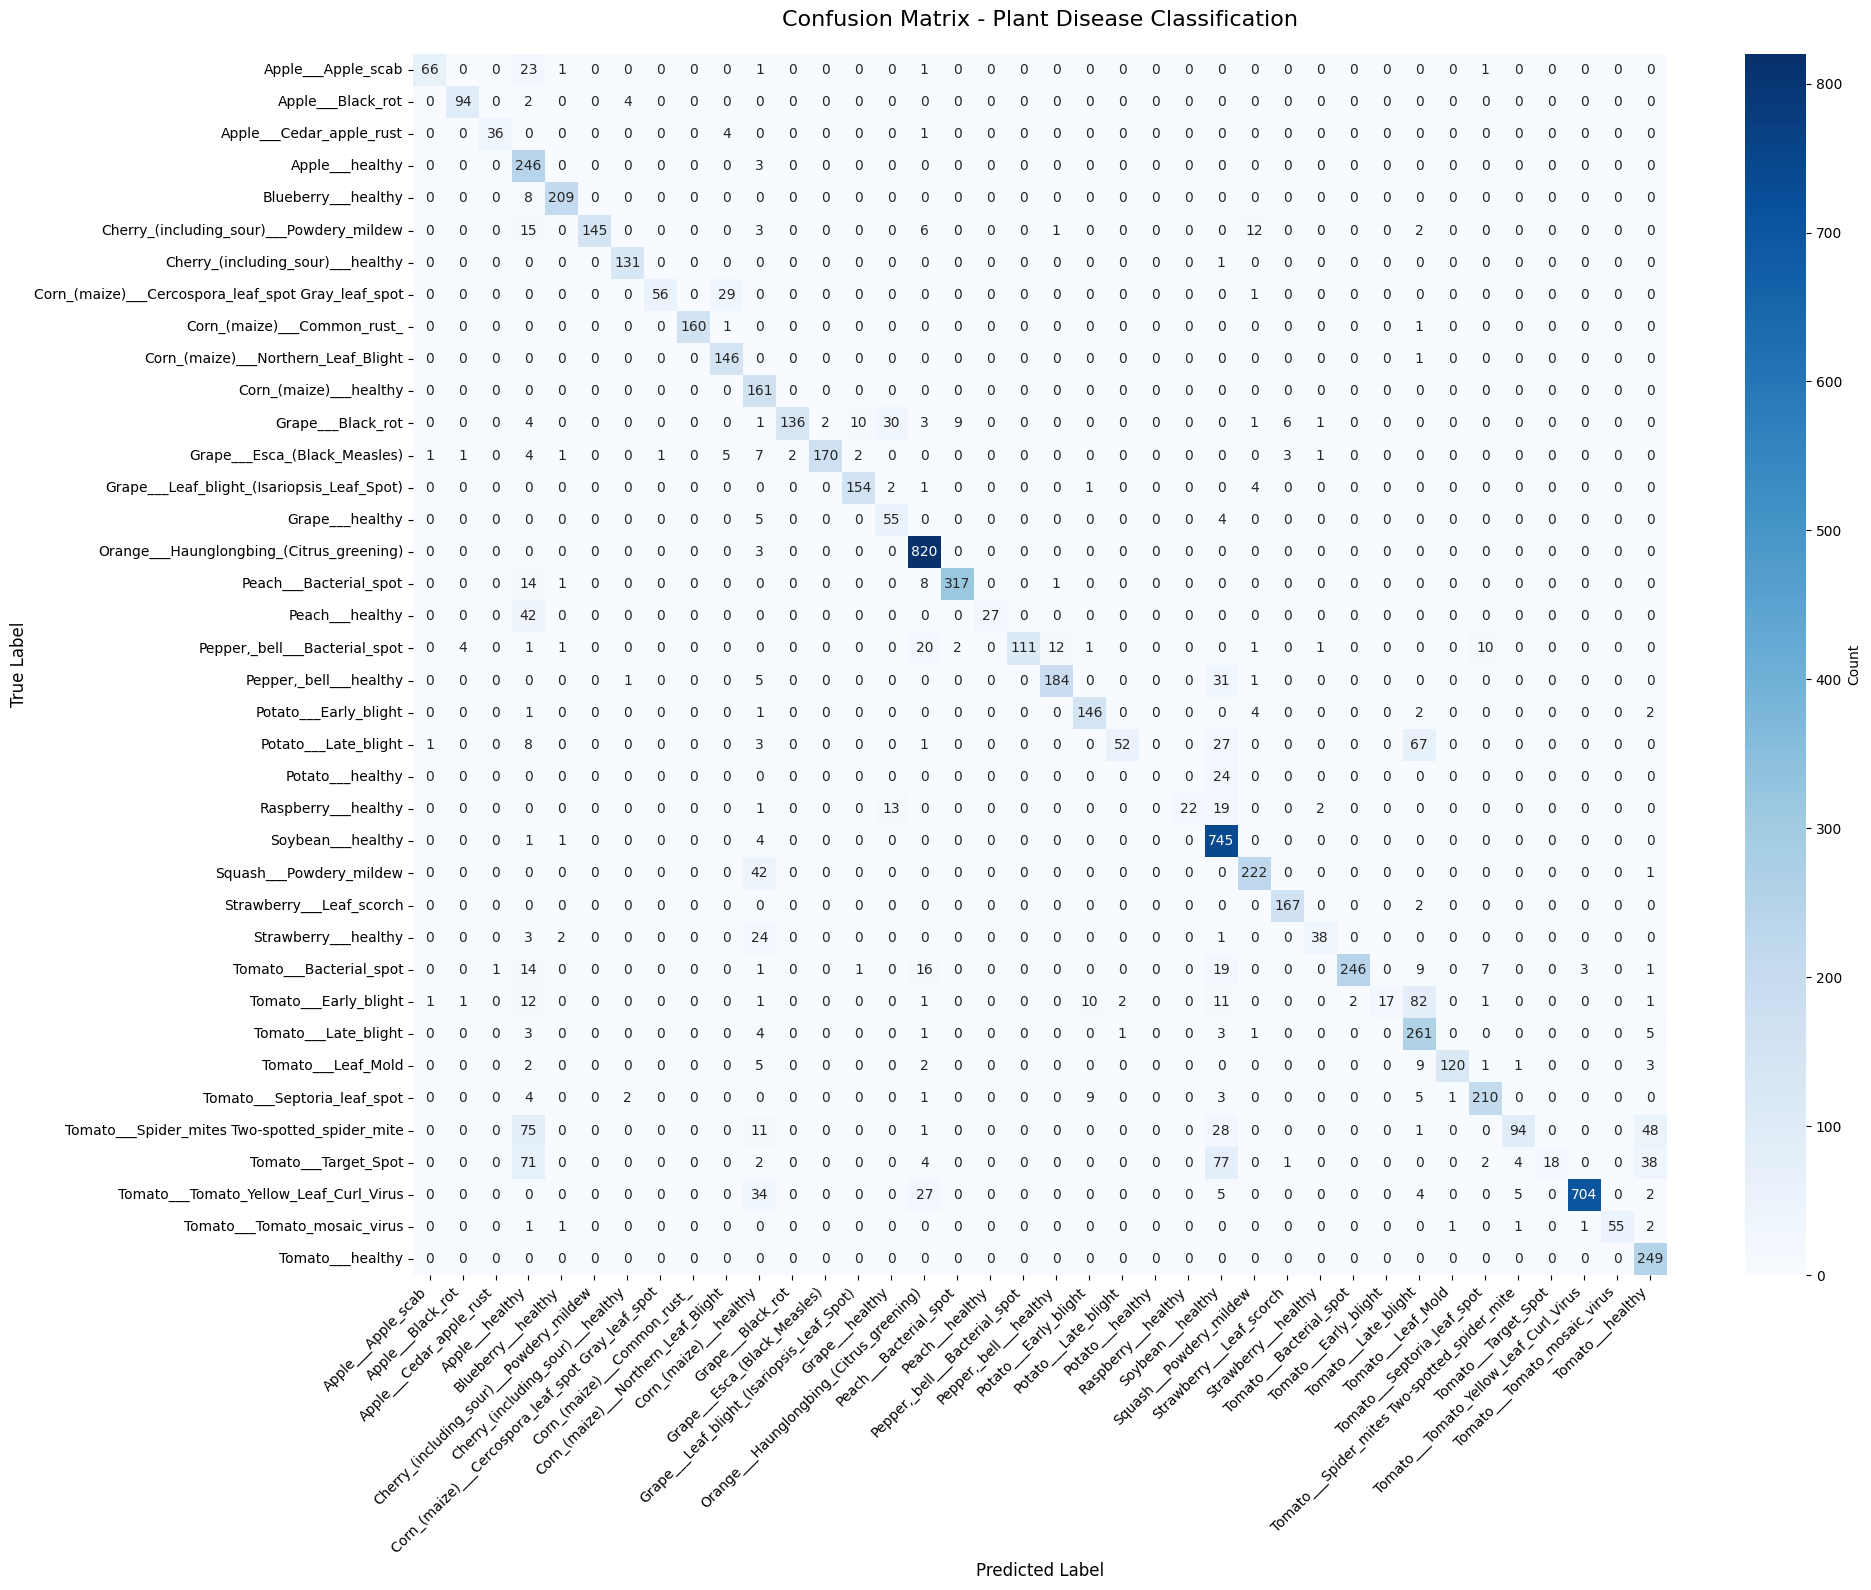


Confusion Matrix Statistics:
Total Predictions: 8151
Correct Predictions: 6790
Misclassifications: 1361
Accuracy: 0.8330


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate confusion matrix using sklearn
cm_sklearn = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(20, 16))
sns.heatmap(cm_sklearn, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Plant Disease Classification', fontsize=16, pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Print confusion matrix statistics
print("\nConfusion Matrix Statistics:")
print("=" * 60)
print(f"Total Predictions: {cm_sklearn.sum()}")
print(f"Correct Predictions: {np.trace(cm_sklearn)}")
print(f"Misclassifications: {cm_sklearn.sum() - np.trace(cm_sklearn)}")
print(f"Accuracy: {np.trace(cm_sklearn) / cm_sklearn.sum():.4f}")
print("=" * 60)
